# To do
- Make bin size smaller (currently 100 ms, try 50 ms)
- CI instead of SEM
- Check usage of labels vs probabilities for predictions accuracy
- Remove misses from analysis! (done in within decoder and epoch cross decoder)
- Use only single units vs MUA
- Cortical neurons (depth < 1.5 mm) vs deep neurons (depth > 1.5 mm)

From meeting with Jaime:
Alexis, remember to make a summary bullet lists from yesterday’s meeting. I think it was quite productive and I feel we have a more clear idea of what to do.
I was thinking a bit more about decoding the stimulus or the choice. Perhaps one way to make it simpler is to:
- Train with ALL engaged trials (correct and error) on
    - predicting the stimulus in stim epoch (Stim Code)
    - predicting the choice in Delay epoch (Delay Code)
    - predicting the choice in licking epoch (Response Code).
I think by combining correct and error trials in the training, it is possible that the Stim Code is not as contaminated by persistent neurons as when you only use correct trials (because in correct trials Stim and choice always match!).
- If you train with all engaged trials using k-fold, you can later compute the decoding accuracy separately for correct and error (engaged) trials by simply separating them in the testing set.

- From Inagaki et al 2022 (MEthods ‘Coding Direction Analusys’), we should take the computation of the Ramp Mode (they call it D_ramp) and the Go Mode (D_Go). In the methods they describe how to compute them. They do not train decoders but simply compute the population vector difference between two average conditions. That gives you a direction vector in the n-space D_X where you can project the activity of the population at any time point of any trial. They kind of cross-validate by computing the direction vector with some trials (training) and projecting some others (testing). But you could apply the same idea of D_ramp and D_Go using the decoders approach:
    - For D_ramp you have to train a decoder to distinguish from population activity two categories: pre-stim vs delay. Each trial contributes therefore with two samples (pre-stim and delay; unlike when training for choice or stim where each trial is always one sample). We will need to think the consequences of this within-trial link between pairs of samples when doing CV.
    - Once you train your pre-stim VS delay decoder, you don’t want to plot the trace of the accuracy because it can be high both in pre-stim and delay epochs, but the prob(decoder says ‘delay’). This prob should go from values under 0.5 in pre-stim epoch to above 0.5 in the delay epoch. Makes sense?

There are some qualitative differences with what you may be finding:
- They see a very clear difference between the Delay code in Right vs Left trials and which corresponds to Contra and Ipsi, resp (they aways record in the Left hemisphere). You could check this by computing the decoder accuracy separately for contra vs ipsi trials (because you do have recordings from the two hemispheres, right?)
- They also see this prestimulus decoding of the stimulus in error trials. It is not clear to me yet, whether this is artifact del slow drift of the neural activity or it is physiological (i.e. there is an imbalance in the activity of choice neurons before the stimulus that generates the error) but it is something which would be worth looking in detail.
- Finally, the see that in miss trials, there are not Lick decoding (obvious), the Delay ramp is lower and the Go mode is there but also kind of lower. They probably have very few miss trials and things look noisy, but still, they have already done quite a bit in this regard.

Jaime, I agree that yesterday was a very productive meeting. This is what I have in my notes, please add anything I might have forgotten:
- Clean neurons that dissappear
    - FR < 1 spike/s --> Remove
    - Use valid trials to compute for every neuron:  var(FR) / mean(FR) per trial. Plot distribution and play with threshold to remove outliers at the tails
- Re-read Ashwood 2022, check where they compare the RTs across states if there're differences
- Cross time decoder:
    - Thinner lines, left align to bin edges
    - Draw horizontal lines -slices- from where sampling later the training epoch for the epoch decoders (stim, delay, response)
- Check code overlap in Tiffany's paper (significance expected between stimulus and delay but not between delay and response)
- Small bump in response code of epoch decoder could be anticipatory licks (to the air) or motor getting stuck in some trials
    - Test hypothesis by removing aberrant licks (licks that happen before response window opens) or by removing those trials and checking if the small bump dissappear
- Repeat analyses but predicitng choice instead of stimulus side (that should make the downward in error trials become mirrored but positive)
- Study Inagaki's and Svoboda's works because they're becoming even more relvant:
    - Thalamus-driven functional populations in frontal cortex support decision-making
    - A midbrain-thalamus-cortex circuit reorganizes cortical dynamics to initiate movement

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ephys.decoder import *
# plt.style.use('default')  # Resets to standard white background
# sns.set_theme()
# sns.set_style('ticks')
# sns.set_context('talk')
# sns.set_context('poster')
from my_fun.my_fun import fig_size, save_notebook_files

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [14]:
# Plotting style
sns.set_theme(style='ticks', context='notebook')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
# %config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'

# Load data

In [4]:
subjects = ['000', '007', '009']  # Removed 001 (all sessions bad)
folder_parent = Path.home() / 'data'

In [5]:
# error_sessions = {s: preprocess_subject(s) for s in subjects}
#
# ephys_ids = {}
# for subject in subjects:
#     ephys_ids[subject] = get_ephys_sessions(subject)
#     ephys_ids[subject] = [id for id in ephys_ids[subject] if id not in error_sessions[subject]]
#
# behavior = {}
# for subject in subjects:
#     folder_parent = Path.home() / 'data' / subject
#     behavior[subject] = []
#     for i in ephys_ids[subject]:
#         path_behavior = get_behavior_id(i)
#         filename = path_behavior.name
#         folder_child = folder_parent / i
#         df = pd.read_csv(folder_child / filename)
#         behavior[subject].append(df)
#
# folder_parent = Path.home() / 'data'

Bad sessions:

- 007
    - '007_2024-07-06_11-16-25'
    - '007_2024-07-07_13-20-29'
    - '007_2024-07-12_13-29-26'. # ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1. Extreme right bias

# Within Temporal Decoder (mean)

Text(0.5, 1.0, 'Decoding accuracy\n3 mice, 25 sessions, 5508 trials')

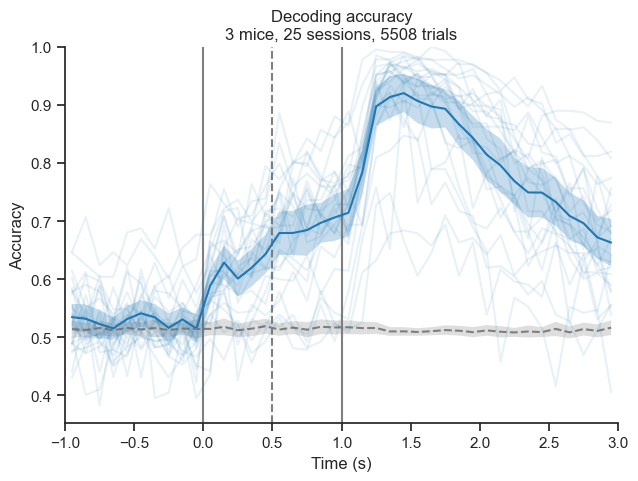

In [19]:
figsize = fig_size(n_cols=1)

keys = ['acc', 'acc_null', 'pred', 'pred_err']
mean_results = {k: [] for k in keys}

for subj in subjects:

    # Run mean within decoder across sessions
    # results = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=1, save=True)

    # Load mean within decoder results across sessions
    # filename = 'results_mean_within_decoder.pkl'  # All trials
    filename = 'stim_within_decoder_hit_only_engaged.pkl'  # Hit only, engaged
    path = Path(folder_parent / subj / filename)
    with open(path, 'rb') as f:
        results = pickle.load(f)

    for k in keys:
        mean_results[k].extend(results.get(k, []))
        mean_results['bins'] = results['bins']

    # # Plot mean within decoder results across sessions for each subject
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_within_decoder(results, z_null=False)
    # n_sessions = len(results['acc'])
    # n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plot_mean_within_decoder(mean_results, z_null=False)
n_sessions = len(mean_results['acc'])
n_trials = np.sum([mean_results['acc'][i].shape[0] for i in range(len(mean_results['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')

# Cross temporal decoder

<Figure size 627x470.25 with 0 Axes>

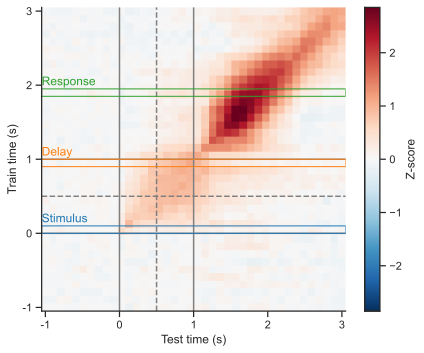

In [8]:
figsize = fig_size(n_cols=1)

keys = ['acc', 'acc_null', 'pred', 'pred_err']
mean_results = {k: [] for k in keys}

for subj in subjects:

    # Run mean cross decoder across sessions
    # results = mean_decoder(kind='cross', save=True)

    # Load mean within decoder results across sessions
    path = Path(folder_parent / subj / 'results_mean_cross_decoder.pkl')
    with open(path, 'rb') as f:
        results = pickle.load(f)

    for k in keys:
        mean_results[k].extend(results.get(k, []))
        mean_results['bins'] = results['bins']

    # # Plot mean cross decoder results across sessions for each subject
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_cross_decoder(results, z_null=True)
    # n_sessions = len(results['acc'])
    # n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plot_mean_cross_decoder(mean_results, z_null=True)
n_sessions = len(mean_results['acc'])
n_trials = np.sum([mean_results['acc'][i].shape[0] for i in range(len(mean_results['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')

## Test

In [ ]:
figsize = fig_size(n_cols=1)

keys = ['acc', 'acc_null', 'pred', 'pred_err']
mean_results = {k: [] for k in keys}

for subj in subjects:

    # Run mean within decoder across sessions
    results = mean_decoder(subj, what='stim', kind='cross', hit_only=True, engagement=1, save=True)

    # # Load mean within decoder results across sessions
    # path = Path(folder_parent / subj / 'results_mean_cross_decoder.pkl')
    # with open(path, 'rb') as f:
    #     results = pickle.load(f)

    for k in keys:
        mean_results[k].extend(results.get(k, []))
        mean_results['bins'] = results['bins']

    # # Plot mean cross decoder results across sessions for each subject
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_cross_decoder(results, z_null=True)
    # n_sessions = len(results['acc'])
    # n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plot_mean_cross_decoder(mean_results, z_null=True)
n_sessions = len(mean_results['acc'])
n_trials = np.sum([mean_results['acc'][i].shape[0] for i in range(len(mean_results['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')

Development mode: local (DESKTOP-FEUIIM1, Usuario, Windows)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Development mode: local (DESKTOP-FEUIIM1, Usuario, Windows)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57
'.npy' files exist in folder. Skipping...
'.csv' files exist in folder. Skipping...
Processing session 2/5: 000_2024-07-09_14-45-54
'.npy' files do not exist in folder. Proceeding...
Development mode: local (DESKTOP-FEUIIM1, Usuario, Windows)

Processor ID: 109, Stream Name: ProbeA-AP, Line: 1 (main sync line))
  First event sample number: 99247421
  Last event sample number: 231584770
  Total sync events: 4464
  Sample rate: 30000.0
Processor ID: 109, Stream Name: ProbeA-LFP, Line: 1 (aux sync line))
  First event sample number: 8270868
  Last eve

Traceback (most recent call last):
  File "C:\Users\Usuario\PycharmProjects\ephys\decoder\decoder.py", line 51, in preprocess_subject
    preprocessed = preprocess(ephys_ids[i])
  File "C:\Users\Usuario\PycharmProjects\my_fun\my_fun.py", line 1043, in wrapper
    result = func(*args, **kwargs)
  File "C:\Users\Usuario\PycharmProjects\ephys\preprocessing\preprocessing.py", line 609, in preprocess
    df_spikes, cluster_info, x, height, labels = load_spike_sorted_data(path_ks4, path_phy2)
                                                 ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Usuario\PycharmProjects\ephys\preprocessing\preprocessing.py", line 282, in load_spike_sorted_data
    spikes_times = np.load(path_ks4 / 'spike_times.npy')  # From KS4
  File "C:\Users\Usuario\anaconda3\envs\analysis\Lib\site-packages\numpy\lib\_npyio_impl.py", line 454, in load
    fid = stack.enter_context(open(os.fspath(file), "rb"))
                              ~~~~^^^^^^^^^^^^^^^^^^^^^^^
F

'.csv' files do not exist in folder. Proceeding...
An error occurred: cannot access local variable 'df_behavior' where it is not associated with a value
Processing session 3/5: 000_2024-07-10_14-32-41
'.npy' files exist in folder. Skipping...
'.csv' files exist in folder. Skipping...
Processing session 4/5: 000_2024-07-11_14-50-25
'.npy' files do not exist in folder. Proceeding...
Development mode: local (DESKTOP-FEUIIM1, Usuario, Windows)

Processor ID: 109, Stream Name: ProbeA-AP, Line: 1 (main sync line))
  First event sample number: 89084136
  Last event sample number: 178380990
  Total sync events: 2994
  Sample rate: 30000.0
Processor ID: 109, Stream Name: ProbeA-LFP, Line: 1 (aux sync line))
  First event sample number: 7423928
  Last event sample number: 14865082
  Total sync events: 2354
  Scale factor: 12.00040396959934
  Actual sample rate: 2499.9158424998936


Traceback (most recent call last):
  File "C:\Users\Usuario\PycharmProjects\ephys\decoder\decoder.py", line 68, in preprocess_subject
    experiment = df_behavior.Experiment.unique()[0]
                 ^^^^^^^^^^^
UnboundLocalError: cannot access local variable 'df_behavior' where it is not associated with a value




Development mode: local (DESKTOP-FEUIIM1, Usuario, Windows)

All sounds sent by Bpod match those received by Arduino
There is(are) 1 more ephys trial(s) than behavior trial(s)
498 trials common to both data sources. Using it for later slicing
All sounds from behavior and ephys match


An error occurred: [Errno 2] No such file or directory: 'C:\\Users\\Usuario\\Downloads\\spike_sorting\\000\\000_2024-07-11_14-50-25\\Phy2\\spike_clusters.npy'


Traceback (most recent call last):
  File "C:\Users\Usuario\PycharmProjects\ephys\decoder\decoder.py", line 51, in preprocess_subject
    preprocessed = preprocess(ephys_ids[i])
  File "C:\Users\Usuario\PycharmProjects\my_fun\my_fun.py", line 1043, in wrapper
    result = func(*args, **kwargs)
  File "C:\Users\Usuario\PycharmProjects\ephys\preprocessing\preprocessing.py", line 609, in preprocess
    df_spikes, cluster_info, x, height, labels = load_spike_sorted_data(path_ks4, path_phy2)
                                                 ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Usuario\PycharmProjects\ephys\preprocessing\preprocessing.py", line 285, in load_spike_sorted_data
    spike_clusters = np.load(path_phy2 / 'spike_clusters.npy')
  File "C:\Users\Usuario\anaconda3\envs\analysis\Lib\site-packages\numpy\lib\_npyio_impl.py", line 454, in load
    fid = stack.enter_context(open(os.fspath(file), "rb"))
                              ~~~~^^^^^^^^^^^^^^^^^^^^^^^
FileNot

'.csv' files do not exist in folder. Proceeding...
An error occurred: cannot access local variable 'df_behavior' where it is not associated with a value
Processing session 5/5: 000_2024-07-12_15-42-10
'.npy' files exist in folder. Skipping...
'.csv' files exist in folder. Skipping...
Sessions not preprocessed: ['000_2024-07-09_14-45-54', '000_2024-07-09_14-45-54', '000_2024-07-11_14-50-25', '000_2024-07-11_14-50-25']
Processing session 1/3: 000_2024-07-08_14-58-57...
Development mode: local (DESKTOP-FEUIIM1, Usuario, Windows)



Traceback (most recent call last):
  File "C:\Users\Usuario\PycharmProjects\ephys\decoder\decoder.py", line 68, in preprocess_subject
    experiment = df_behavior.Experiment.unique()[0]
                 ^^^^^^^^^^^
UnboundLocalError: cannot access local variable 'df_behavior' where it is not associated with a value


Disengagement in trial 220


To do:
- Horizontal lines showing the 'temporal slices' (stimulus, delay, go cue) corresponding to the epochs of interest in epoch cross decoder

# Epoch Cross Temporal Decoder (mean)

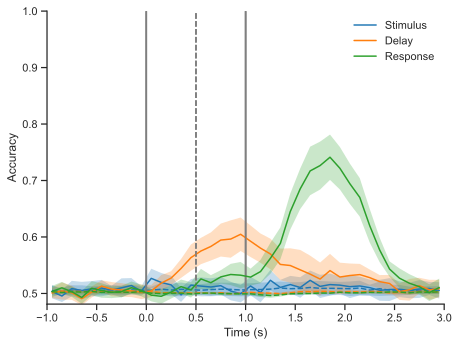

In [9]:
figsize = fig_size(n_cols=1)

keys = ['acc', 'acc_null', 'pred', 'pred_err']

mean_results_stim = {k: [] for k in keys}
mean_results_delay = {k: [] for k in keys}
mean_results_resp = {k: [] for k in keys}

for subj in subjects:

    # Run mean epoch cross decoder across sessions
    # results_stim = mean_decoder(kind='epoch', epoch='stim', save=True)
    # results_delay = mean_decoder(kind='epoch', epoch='delay', save=True)
    # results_resp = mean_decoder(kind='epoch', epoch='resp', save=True)

    # Load mean epoch cross decoder results across sessions
    with open(Path(folder_parent / subj / 'results_mean_epoch_cross_decoder_stim.pkl'), 'rb') as f:
        results_stim = pickle.load(f)
    with open(Path(folder_parent / subj / 'results_mean_epoch_cross_decoder_delay.pkl'), 'rb') as f:
        results_delay = pickle.load(f)
    with open(Path(folder_parent / subj /'results_mean_epoch_cross_decoder_resp.pkl'), 'rb') as f:
        results_resp = pickle.load(f)

    for k in keys:
        mean_results_stim[k].extend(results_stim.get(k, []))
        mean_results_stim['bins'] = results_stim['bins']
        mean_results_delay[k].extend(results_delay.get(k, []))
        mean_results_delay['bins'] = results_delay['bins']
        mean_results_resp[k].extend(results_resp.get(k, []))
        mean_results_resp['bins'] = results_resp['bins']

    # # Plot mean epoch cross decoder results across sessions
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_epoch_cross_decoder(results_stim, epoch='stim', errorbar='ci', z_null=False)
    # plot_mean_epoch_cross_decoder(results_delay, epoch='delay', errorbar='ci', z_null=False)
    # plot_mean_epoch_cross_decoder(results_resp, epoch='resp', errorbar='ci', z_null=False)
    # n_sessions = len(results_stim['acc'])
    # n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plot_mean_epoch_cross_decoder(mean_results_stim, epoch='stim', errorbar='ci', z_null=False)
plot_mean_epoch_cross_decoder(mean_results_delay, epoch='delay', errorbar='ci', z_null=False)
plot_mean_epoch_cross_decoder(mean_results_resp, epoch='resp', errorbar='ci', z_null=False)
n_sessions = len(mean_results['acc'])
n_trials = np.sum([mean_results['acc'][i].shape[0] for i in range(len(mean_results['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')

To do:
- Code overlap between stim and delay in epoch cross decoder (see Tiffany's paper Fig. 3g)
- Small bump in response code could be anticipatory licking (licks to the air). It could also be the motor getting stuck in the previous trial and not going back, therefore representing aberrant licks (licks that shouldn't be there). Check if there are aberrant licks (licks before the response window opens), remove them and see if the small bump disappears.

## ORTHOGONALIZATION TEST: Epoch Cross Temporal Decoder (mean)

NameError: name 'subject' is not defined

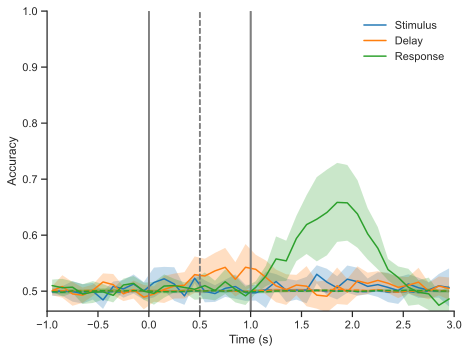

In [10]:
%%time
# Run mean epoch cross decoder across sessions
# results_stim = mean_decoder(kind='epoch_ortho', epoch='stim', epoch_ortho='delay', engagement=1, save=False)
# results_delay = mean_decoder(kind='epoch_ortho', epoch='delay', epoch_ortho='stim', engagement=1, save=False)
# results_resp = mean_decoder(kind='epoch_ortho', epoch='resp', epoch_ortho='delay', engagement=1, save=False)

# Load mean epoch cross decoder results across sessions
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_engaged.pkl'), 'rb') as f:
#     results_stim = pickle.load(f)
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_engaged.pkl'), 'rb') as f:
#     results_delay = pickle.load(f)
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp_engaged.pkl'), 'rb') as f:
#     results_resp = pickle.load(f)

# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_stim, epoch='stim', errorbar='ci', z_null=False)
plot_mean_epoch_cross_decoder(results_delay, epoch='delay', errorbar='ci', z_null=False)
plot_mean_epoch_cross_decoder(results_resp, epoch='resp', errorbar='ci', z_null=False)
n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

In [11]:
%%time
# Run mean epoch cross decoder across sessions
results_stim = mean_decoder(kind='epoch_ortho', epoch='stim', epoch_ortho='stim', engagement=1, save=False)
# results_delay = mean_decoder(kind='epoch_ortho', epoch='delay', epoch_ortho='stim', engagement=1, save=False)
# results_resp = mean_decoder(kind='epoch_ortho', epoch='resp', epoch_ortho='delay', engagement=1, save=False)

# Load mean epoch cross decoder results across sessions
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_engaged.pkl'), 'rb') as f:
#     results_stim = pickle.load(f)
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_engaged.pkl'), 'rb') as f:
#     results_delay = pickle.load(f)
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp_engaged.pkl'), 'rb') as f:
#     results_resp = pickle.load(f)

# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_stim, epoch='stim', errorbar='ci', z_null=False)
# plot_mean_epoch_cross_decoder(results_delay, epoch='delay', errorbar='ci', z_null=False)
# plot_mean_epoch_cross_decoder(results_resp, epoch='resp', errorbar='ci', z_null=False)
n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

TypeError: mean_decoder() missing 1 required positional argument: 'subject'

# Epoch Cross Temporal Decoder Split (mean)

## Stimulus code split by Outcome (blue trace in mean epoch cross temporal decoder)
2 approaches that should lead to the same mean accuracy but **different** null accuracy:
1. Run the epoch cross decoder function above for all trials and then average across trial types according to split (e.g. splitting by outcome in correct/error trials). Mean null  accuracy should be the **same** for each split (flat at 0.5). This is **wrong**
2. Run the epoch cross decoder split function that performs the split when training the decoder. Mean null accuracy should be **different** for each split. This is **correct**

### 1. Run epoch cross decoder function for all trials and average across trial types

In [12]:
# Split stim decoder into correct vs error trials
# behavior = [behavior[i][behavior[i].Miss==0].reset_index(drop=True) for i in range(len(behavior))]
indexes = [get_trial_indexes(behavior[i], condition='outcome') for i in range(len(behavior))]
# indexes = [get_trial_indexes(behavior[i][behavior[i].Miss==0].reset_index(drop=True), condition='outcome') for i in range(len(behavior))]

# hits = [list(np.where(behavior[i].Hit == True)[0]) for i in range(len(behavior))]
# errors = [list(np.where(behavior[i].Hit == False)[0]) for i in range(len(behavior))]
# misses = [np.where(np.isnan(behavior[i].Hit))[0] for i in range(len(behavior))]
# indexes = [[h, e] for h, e in zip(hits, errors)]

# Error trials
acc_mean_error = [np.nanmean(results_stim['acc'][i][indexes[i][0]], axis=0) for i in range(len(results_stim['acc']))]
acc_mean_error = np.array(acc_mean_error)
acc_sem_error = sem(acc_mean_error, axis=0, nan_policy='omit')
acc_mean_error = np.mean(acc_mean_error, axis=0)
acc_null_mean_error = [np.nanmean(results_stim['acc_null'][i][indexes[i][0]], axis=(0, 2)) for i in range(len(results_stim['acc_null']))]
acc_null_mean_error = np.array(acc_null_mean_error)
acc_null_mean_error = np.nanmean(acc_null_mean_error, axis=0)

# Correct trials
acc_mean_correct = [np.nanmean(results_stim['acc'][i][indexes[i][1]], axis=0) for i in range(len(results_stim['acc']))]
acc_mean_correct = np.array(acc_mean_correct)
acc_sem_correct = sem(acc_mean_correct, axis=0, nan_policy='omit')
acc_mean_correct = np.nanmean(acc_mean_correct, axis=0)
acc_null_mean_correct = [np.nanmean(results_stim['acc_null'][i][indexes[i][1]], axis=(0, 2)) for i in range(len(results_stim['acc_null']))]
acc_null_mean_correct = np.array(acc_null_mean_correct)
acc_null_mean_correct = np.nanmean(acc_null_mean_correct, axis=0)

plt.figure(constrained_layout=True)

# Error trials
plt.plot(results_stim['bins'][:-1], acc_mean_error, color='tab:red', label='Error')
plt.fill_between(results_stim['bins'][:-1], acc_mean_error - acc_sem_error,
                 acc_mean_error + acc_sem_error, color='tab:red', edgecolor='none',
                 alpha=0.25)
plt.plot(results_stim['bins'][:-1], acc_null_mean_error, color='tab:red', ls='--')

# Correct trials
plt.plot(results_stim['bins'][:-1], acc_mean_correct, color='tab:green', label='Correct')
plt.fill_between(results_stim['bins'][:-1], acc_mean_correct - acc_sem_correct,
                 acc_mean_correct + acc_sem_correct, color='tab:green', edgecolor='none',
                 alpha=0.25)
plt.plot(results_stim['bins'][:-1], acc_null_mean_correct, color='tab:green', ls='--')

n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')
plt.xlabel('Time (s)')
plt.ylabel('Accuracy')
plt.legend(frameon=False)
sns.despine()

NameError: name 'behavior' is not defined

Note the same mean null accuracy for both splits. This is wrong.

### 2. Run epoch cross decoder split function that performs the split when training the decoder

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
# results_stim = mean_decoder(kind='epoch_split', epoch='stim', split_by='Hit', engagement=1, save=True)

# Load epoch cross decoder split results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_split_by_Hit.pkl'), 'rb') as f:
    results_stim = pickle.load(f)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_stim, errorbar='ci', z_null=True)
n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i][0].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Save figure
filename = 'mean_epoch_stim_split_hit_decoder_007_(train-test_within_label)'
plt.savefig(Path(folder_out / (filename + '.' + 'svg')), format='svg', transparent=False)

Note the different mean null accuracy for both splits. This is correct.

Accuracy remains relatively stable around chance (~0.5) before stimulus onset (0s). A transient increase in decoding accuracy around 0s in correct trials, but no strong sustained difference between error and correct trials.
After ~1s, accuracy for correct trials trends slightly higher than for errors, but the separation is modest. For error trials the shuffles closely follow the downward trend of the code because in every error trial the animal licked to the opposite side of stimulus (what I am decoding).
What is more weird is that there's also a lot of code in correct trials's shuffles. It could be a bias.

In errors the stimulus is well represented, but the mouse prepare (delay) and execute (response) the wrong choice.

## Delay code split by Outcome (orange trace in mean epoch cross temporal decoder)

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
# results_delay = mean_decoder(kind='epoch_split', epoch='delay', split_by='Hit', engagement=1, save=True)

# Load epoch cross decoder split results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_split_by_Hit.pkl'), 'rb') as f:
    results_delay = pickle.load(f)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_delay, epoch='delay', split='hit', errorbar='ci', z_null=True)
n_sessions = len(results_delay['acc'])
n_trials = np.sum([results_delay['acc'][i][0].shape[0] for i in range(len(results_delay['acc']))])
plt.title(f'Delay code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Save figure
filename = 'mean_epoch_delay_split_hit_decoder_007_(train-test_within_label)'
plt.savefig(Path(folder_out / (filename + '.' + 'svg')), format='svg', transparent=False)

## Response code split by Outcome (green trace in mean epoch cross temporal decoder)

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
# results_resp = mean_decoder(kind='epoch_split', epoch='resp', split_by='Hit', engagement=1, save=True)

# Load epoch cross decoder split results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp_split_by_Hit.pkl'), 'rb') as f:
    results_resp = pickle.load(f)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_resp, epoch='resp', split='hit', errorbar='ci', z_null=True)
n_sessions = len(results_resp['acc'])
n_trials = np.sum([results_resp['acc'][i][0].shape[0] for i in range(len(results_resp['acc']))])
plt.title(f'Response code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Save figure
filename = 'mean_epoch_resp_split_hit_decoder_007_(train-test_within_label)'
plt.savefig(Path(folder_out / (filename + '.' + 'svg')), format='svg', transparent=False)

Larger accuracy in correct trials because there is reward and therefore more licks.

# Engagement
Testing comparison of (stimulus) decoding accuracy of epoch cross decoder between engagement states (engaged vs disengaged)

## Stimulus

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
# results_stim_disengaged = mean_decoder(kind='epoch', epoch='stim', engagement=0, save=True)
# results_stim_engaged = mean_decoder(kind='epoch', epoch='stim', engagement=1, save=True)

# Load mean epoch cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_disengaged.pkl'), 'rb') as f:
    results_stim_disengaged = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_engaged.pkl'), 'rb') as f:
    results_stim_engaged = pickle.load(f)

# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_stim_disengaged, epoch='stim', engagement=0, z_null=False)
plot_mean_epoch_cross_decoder(results_stim_engaged, epoch='stim', engagement=1, z_null=False)
n_sessions = len(results_stim_disengaged['acc'])
n_trials = np.sum([(results_stim_disengaged['acc'][i].shape[0] + results_stim_engaged['acc'][i].shape[0]) for i in range(len(results_stim_disengaged['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Save figure
filename = 'mean_epoch_stim_split_engagement_decoder_007_(train-test_within_label)'
plt.savefig(Path(folder_out / (filename + '.' + 'svg')), format='svg', transparent=False)

## Delay

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
# results_delay_disengaged = mean_decoder(kind='epoch', epoch='delay', engagement=0, save=True)
# results_delay_engaged = mean_decoder(kind='epoch', epoch='delay', engagement=1, save=True)

# Load mean epoch cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_disengaged.pkl'), 'rb') as f:
    results_delay_disengaged = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_engaged.pkl'), 'rb') as f:
    results_delay_engaged = pickle.load(f)

# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_delay_disengaged, epoch='delay', engagement=0, z_null=False)
plot_mean_epoch_cross_decoder(results_delay_engaged, epoch='delay', engagement=1, z_null=False)
n_sessions = len(results_delay_disengaged['acc'])
n_trials = np.sum([(results_delay_disengaged['acc'][i].shape[0] + results_delay_engaged['acc'][i].shape[0]) for i in range(len(results_delay_disengaged['acc']))])
plt.title(f'Delay code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Save figure
filename = 'mean_epoch_delay_split_engagement_decoder_007_(train-test_within_label)'
plt.savefig(Path(folder_out / (filename + '.' + 'svg')), format='svg', transparent=False)

## Response

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
# results_resp_disengaged = mean_decoder(kind='epoch', epoch='resp', engagement=0, save=True)
# results_resp_engaged = mean_decoder(kind='epoch', epoch='resp', engagement=1, save=True)

# Load mean epoch cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp_disengaged.pkl'), 'rb') as f:
    results_resp_disengaged = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp_engaged.pkl'), 'rb') as f:
    results_resp_engaged = pickle.load(f)

# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_resp_disengaged, epoch='resp', engagement=0, z_null=False)
plot_mean_epoch_cross_decoder(results_resp_engaged, epoch='resp', engagement=1, z_null=False)
n_sessions = len(results_resp_disengaged['acc'])
n_trials = np.sum([(results_resp_disengaged['acc'][i].shape[0] + results_resp_engaged['acc'][i].shape[0]) for i in range(len(results_resp_disengaged['acc']))])
plt.title(f'Response code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Save figure
filename = 'mean_epoch_resp_split_engagement_decoder_007_(train-test_within_label)'
plt.savefig(Path(folder_out / (filename + '.' + 'svg')), format='svg', transparent=False)

## Train in correct trials, test in error trials

### All trials

In [ ]:
%%time
results_all_trials = mean_decoder(kind='test', epoch='stim', split_by='Hit', engagement=None, save=False)

plot_mean_epoch_cross_decoder_split(results_all_trials, z_null=True)
n_sessions = len(results_all_trials['acc'])
n_trials = np.sum([results_all_trials['acc'][i][0].shape[0] for i in range(len(results_all_trials['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

### Engaged trials only

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
results_stim_engaged = mean_decoder(kind='test', epoch='stim', split_by='Hit', engagement=1, n_shuffles=100, save=False)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_stim_engaged, epoch='stim', split='hit', errorbar='ci', z_null=True)
n_sessions = len(results_stim_engaged['acc'])
n_trials = np.sum([results_stim_engaged['acc'][i][0].shape[0] for i in range(len(results_stim_engaged['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Save figure
filename = 'mean_epoch_stim_split_hit_decoder_007_(train_correct_test_error)'
plt.savefig(Path(folder_out / (filename + '.' + 'svg')), format='svg', transparent=False)

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
results_delay_engaged = mean_decoder(kind='test', epoch='delay', split_by='Hit', engagement=1, n_shuffles=1000, save=False)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_delay_engaged, epoch='delay', split='hit', errorbar='ci', z_null=True)
n_sessions = len(results_stim_engaged['acc'])
n_trials = np.sum([results_delay_engaged['acc'][i][0].shape[0] for i in range(len(results_delay_engaged['acc']))])
plt.title(f'Delay code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Save figure
filename = 'mean_epoch_delay_split_hit_decoder_007_(train_correct_test_error)'
plt.savefig(Path(folder_out / (filename + '.' + 'svg')), format='svg', transparent=False)

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
results_resp_engaged = mean_decoder(kind='test', epoch='resp', split_by='Hit', engagement=1, n_shuffles=1000, save=False)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_resp_engaged, epoch='resp', split='hit', errorbar='ci', z_null=True)
n_sessions = len(results_resp_engaged['acc'])
n_trials = np.sum([results_resp_engaged['acc'][i][0].shape[0] for i in range(len(results_resp_engaged['acc']))])
plt.title(f'Response code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Save figure
filename = 'mean_epoch_resp_split_hit_decoder_007_(train_correct_test_error)
plt.savefig(Path(folder_out / (filename + '.' + 'svg')), format='svg', transparent=False)

## Train in correct engaged trials, test in correct disengaged trials

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
results_stim_correct = mean_decoder(kind='test', epoch='stim', split_by='Engaged', engagement=None, drop_miss=True, hit_only=True, save=False)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_stim_correct, epoch='stim', errorbar='ci', split='engagement', z_null=True)
n_sessions = len(results_stim_correct['acc'])
n_trials = np.sum([results_stim_correct['acc'][i][0].shape[0] for i in range(len(results_stim_correct['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')
plt.legend(frameon=False)

# Save figure
filename = 'mean_epoch_stim_split_engagement_decoder_007_(train_engaged_test_disengaged)'
plt.savefig(Path(folder_out / (filename + '.' + 'svg')), format='svg', transparent=False)

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
results_delay_correct = mean_decoder(kind='test', epoch='delay', split_by='Engaged', engagement=None, drop_miss=True, hit_only=True, save=False)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_delay_correct, epoch='delay' , errorbar='ci', split='engagement', z_null=True)
n_sessions = len(results_delay_correct['acc'])
n_trials = np.sum([results_delay_correct['acc'][i][0].shape[0] for i in range(len(results_delay_correct['acc']))])
plt.title(f'Delay code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Save figure
filename = 'mean_epoch_delay_split_engagement_decoder_007_(train_engaged_test_disengaged)'
plt.savefig(Path(folder_out / (filename + '.' + 'svg')), format='svg', transparent=False)

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
results_resp_correct = mean_decoder(kind='test', epoch='resp', split_by='Engaged', engagement=None, drop_miss=True, hit_only=True, save=False)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_resp_correct, epoch='resp', errorbar='ci', split='engagement', z_null=True)
n_sessions = len(results_resp_correct['acc'])
n_trials = np.sum([results_resp_correct['acc'][i][0].shape[0] for i in range(len(results_resp_correct['acc']))])
plt.title(f'Response code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Save figure
filename = 'mean_epoch_resp_split_engagement_decoder_007_(train_engaged_test_disengaged)'
plt.savefig(Path(folder_out / (filename + '.' + 'svg')), format='svg', transparent=False)

# Population selectivity analysis

From:
Inagaki, H. K., Chen, S., Ridder, M. C., Sah, P., Li, N., Yang, Z., Hasanbegovic, H., Gao, Z., Gerfen, C. R., & Svoboda, K. (2022). A midbrain-thalamus-cortex circuit reorganizes cortical dynamics to initiate movement. Cell, 185(6), 1065-1081.e23. https://doi.org/10.1016/j.cell.2022.02.006

In [77]:
# Align to stimulus onset
df_behavior = behavior[0]
bins = np.load(folder_parent / ephys_ids[0] / 'bins.npy')
all_psth = np.load(folder_parent / ephys_ids[0] / 'all_psth.npy')

# Step 1: Separate trials by condition
left_lick_trials = df_behavior[df_behavior.Choice == 0].Trial
right_lick_trials = df_behavior[df_behavior.Choice == 1].Trial

# Step 2: Compute mean firing rates per time bin
r_lick_left = np.mean(all_psth[left_lick_trials], axis=0)  # shape (bins, neurons)
r_lick_right = np.mean(all_psth[right_lick_trials], axis=0)  # shape (bins, neurons)

# Step 3: Compute selectivity vector w_t
wt = r_lick_right - r_lick_left  # shape (bins, neurons)

# Step 4: Perform SVD to get the dominant coding direction
U, S, Vt = np.linalg.svd(wt, full_matrices=False)

# Step 5: CD_delay is the first right singular vector (principal axis)
CD_delay = Vt[0, :]  # First singular vector (neurons,)

# Step 6: Normalize to unit vector
CD_delay /= np.linalg.norm(CD_delay)

# Step 7: Compute correlation matrix
corr_matrix = np.corrcoef(wt)
# np.fill_diagonal(corr_matrix, np.nan)  # Remove diagonal by setting it to NaN

# Step 8: Plot correlation matrix
plt.figure(constrained_layout=True)
plt.imshow(corr_matrix, cmap='coolwarm', origin='lower')
plt.axhline(np.where(bins == 0)[0], color='k', linestyle='-')  # Stimulus onset
plt.axvline(np.where(bins == 0)[0], color='k', linestyle='-')  # Stimulus onset
plt.axhline(np.where(bins == 0.5)[0], color='k', linestyle='-')  # Delay
plt.axvline(np.where(bins == 0.5)[0], color='k', linestyle='-')  # Delay
plt.axhline(np.where(bins == 1)[0], color='k', linestyle='-')  # Go cue
plt.axvline(np.where(bins == 1)[0], color='k', linestyle='-')  # Go cue
plt.xticks(np.arange(0, len(bins), 10), np.round(bins[::10]).astype(int))
plt.yticks(np.arange(0, len(bins), 10), np.round(bins[::10]).astype(int))
plt.colorbar(label="Pearson's correlation\nof selectivity vector")
plt.xlabel('Time from stim. onset (s)')
plt.ylabel('Time from stim. onset (s)')
# plt.title('Correlation of Population Selectivity Over Time')
sns.despine()

NameError: name 'behavior' is not defined

Pearson's correlation is high during the delay epoch (0.5-1 s), meaning that a similar subpopulation of neurons holds selectivity during motor planning. In contrast, population selectivity show a low correlation before and after the Go cue (1 s), meaning that different subpopulations of neurons show selectivity. Population activity patterns in M2 change rapidly before and during movement initiation.

In [ ]:
# Compute the total number of trials in behavior
total_trials = sum([df.shape[0] for df in behavior])
print('Total trials:', total_trials)

# Compute the total number of trials in behavior that were misses
total_missed = sum([df[df.Miss == 1].shape[0] for df in behavior])
print('Total missed:', total_missed)

# Compute the total number of trials in behavior that were responses
total_responded = sum([df[df.Response == 1].shape[0] for df in behavior])
print('Total responded:', total_responded)

# Check if the total number of trials equals the sum of missed and responded trials
assert (total_trials == total_missed + total_responded), \
    f"Total trials {total_trials} do not equal to missed trials {total_missed} + response trials {total_responded}"

In [ ]:
import ast

# Merge all behavior dataframes in a single one
df_behavior_all = pd.concat(behavior, ignore_index=True)

# Keep nly engaged trials
df_behavior_all = df_behavior_all[df_behavior_all.Engaged == 1].reset_index(drop=True)

# Convert Port1In and Port2In columns to lists of floats (from list of strings)
df_behavior_all["Port1In"] = df_behavior_all["Port1In"].apply(lambda x: ast.literal_eval(x.strip()))
df_behavior_all["Port2In"] = df_behavior_all["Port2In"].apply(lambda x: ast.literal_eval(x.strip()))

In [ ]:
peri_stim_licks = get_peri_stim_licks(df_behavior_all)
bins, licks_psth = compute_psth(peri_stim_licks)
fig, ax = plt.subplots()
plot_psth_split(condition='outcome', over='licks', ax=ax)

# Remove top and right spines
sns.despine()

# Add legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=False)
n_sessions = len(results_resp['acc'])
n_trials = np.sum([results_resp['acc'][i][0].shape[0] for i in range(len(results_resp['acc']))])
plt.title(f'Lick PSTH\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Save figure
filename = 'mean_lick_rate_split_outcome_engaged_only'
plt.savefig(Path(folder_out / (filename + '.' + 'svg')), format='svg', transparent=False)

# Save all notebook's figures

In [64]:
# # Whole notebook ouputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
save_notebook_files('notebook.ipynb')

Saved 3 images to notebook_files/
